# Imperial College Data Engineering Final Project: Segmented Clustering Analysis

This Notebook contains the refactored data engineering pipeline and machine learning clustering analysis. 

Based on the latest requirements, rather than clustering all vehicles collectively, we first map the dataset into 4 Macro-Classes. We then perform feature scaling and clustering analysis **independently within each macro-class**. This "Segmented Peer Benchmarking" approach enables us to accurately discover the true best-in-class models and extreme outliers within their specific competitive segments.

---

## Phase 1: Environment Setup & Data Ingestion

In [7]:
# ==========================================
# Phase 1: Environment Setup & Data Ingestion (Proper Data Enrichment)
# ==========================================
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')
os.environ["OMP_NUM_THREADS"] = "1"

# 1. Read Original Data (Contains Make and Model)
from pathlib import Path

data_path = Path("../Data/CO2 Emissions_Canada.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "The file 'CO2 Emissions_Canada.csv' was not found at '../Data/CO2 Emissions_Canada.csv'. "
        "Check that the dataset is inside the Data folder and that the notebook is being run from the Notebooks folder."
    )

df_raw = pd.read_csv(data_path)
df_raw.head()
print(f" Raw Layer Data Shape: {df_raw.shape}")

# 2. Read Clean Data (Andrew's base dataset, 4932 rows)
df_clean = pd.read_csv("../Data/Clean dataset.csv")

# 3.  True Data Enrichment (Recover Make & Model via deterministic matching)
# Extract all column names from the Clean dataset as a "matching fingerprint"
match_cols = df_clean.columns.tolist()

# Deduplicate raw data on match columns to prevent row inflation from identical records
df_raw_unique = df_raw.drop_duplicates(subset=match_cols, keep='first')

# Left Join: recover Make and Model from raw data using 10 physical + consumption parameters as join keys
df_silver = pd.merge(df_clean, df_raw_unique[['Make', 'Model'] + match_cols], on=match_cols, how='left')

# Fill any unmatched records (due to minor precision discrepancies) with placeholder values
df_silver['Make'] = df_silver['Make'].fillna('Unknown Make')
df_silver['Model'] = df_silver['Model'].fillna('Unknown Model')

# Define all numerical columns required for DBSCAN distance computation
num_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 
            'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 
            'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)']

print(f" Clean Data Shape: {df_clean.shape}")
print(f" Silver Layer (Properly Enriched) Data Shape: {df_silver.shape}")

 Raw Layer Data Shape: (7385, 12)
 Clean Data Shape: (4932, 10)
 Silver Layer (Properly Enriched) Data Shape: (4932, 12)


## Phase 2: Data Cleaning & Macro-Class Mapping
We aggregate identical vehicle models by calculating the mean of their features to reduce noise, and map the original 16 granular `Vehicle Class` categories into 4 designated Macro-Classes.

In [8]:
# ==========================================
# Phase 2: Data Cleaning & Macro-Class Mapping
# ==========================================
class_mapping = {
    'MINICOMPACT': 'Small Passenger Vehicles',
    'SUBCOMPACT': 'Small Passenger Vehicles',
    'COMPACT': 'Small Passenger Vehicles',
    'TWO-SEATER': 'Small Passenger Vehicles',
    'STATION WAGON - SMALL': 'Small Passenger Vehicles',
    
    'MID-SIZE': 'Midsize & Large Passenger Vehicles',
    'FULL-SIZE': 'Midsize & Large Passenger Vehicles',
    'STATION WAGON - MID-SIZE': 'Midsize & Large Passenger Vehicles',
    
    'SUV - SMALL': 'SUVs & Minivans',
    'SUV - STANDARD': 'SUVs & Minivans',
    'MINIVAN': 'SUVs & Minivans',
    
    'PICKUP TRUCK - SMALL': 'Trucks, Vans & Specialty Utility',
    'PICKUP TRUCK - STANDARD': 'Trucks, Vans & Specialty Utility',
    'VAN - CARGO': 'Trucks, Vans & Specialty Utility',
    'VAN - PASSENGER': 'Trucks, Vans & Specialty Utility',
    'SPECIAL PURPOSE VEHICLE': 'Trucks, Vans & Specialty Utility'
}

df_silver['Macro_Class'] = df_silver['Vehicle Class'].map(class_mapping)

# Extract Transmission Type (letters) and Gear num (numbers) using regex
df_silver['Transmission Type'] = df_silver['Transmission'].str.extract(r'([A-Za-z]+)')
df_silver['Gear num'] = df_silver['Transmission'].str.extract(r'(\d+)').astype(float).fillna(0)

df_gold_temp = df_silver.drop(columns=['Transmission'])

# One-Hot Encoding for categorical variables
df_gold = pd.get_dummies(df_gold_temp, columns=['Vehicle Class', 'Transmission Type', 'Fuel Type'], drop_first=False)
print(f" Gold Layer (Before Split) Data Shape: {df_gold.shape}")

 Gold Layer (Before Split) Data Shape: (4932, 37)


## Phase 3: Group-wise Scaling & Clustering

**Core Logic:** We cannot fairly compare a compact car with a heavy-duty pickup truck on the exact same scale. Therefore, we iterate through the 4 Macro-Classes and independently apply `StandardScaler` within each category before running K-Means and DBSCAN. This ensures that we discover the true "black tech" (innovative efficiency leaders) and "gas guzzlers" (extreme underperformers) strictly within the same vehicle tier.

In [9]:
# ==========================================
# Phase 3: Group-wise Scaling & Dual-Track Clustering Analysis
# ==========================================
clustered_results = []
print(" Starting independent clustering analysis...\n")

macro_classes = df_silver['Macro_Class'].dropna().unique()

# Define purely physical numerical features for K-MEANS
physical_numeric_cols = ['Engine Size(L)', 'Cylinders', 'Gear num']

# Define Andrew's optimal K values
andrew_k_values = {
    'Small Passenger Vehicles': 5,
    'Midsize & Large Passenger Vehicles': 4, 
    'SUVs & Minivans': 4,
    'Trucks, Vans & Specialty Utility': 5
}

for macro in macro_classes:
    print(f" Processing Category: {macro}")
    
    idx = df_silver[df_silver['Macro_Class'] == macro].index
    sub_silver = df_silver.loc[idx].copy()
    sub_gold = df_gold.loc[idx].copy()
    
    # ==========================================
    #  Track A: K-Means (Blind Physical Clustering aligned with Andrew)
    # ==========================================
    scaler_kmeans = StandardScaler()
    sub_gold_kmeans = sub_gold.copy()
    sub_gold_kmeans[physical_numeric_cols] = scaler_kmeans.fit_transform(sub_gold_kmeans[physical_numeric_cols])
    
    cat_encoded_cols = [c for c in sub_gold_kmeans.columns if c.startswith('Transmission Type_') or c.startswith('Fuel Type_')]
    X_kmeans = sub_gold_kmeans[physical_numeric_cols + cat_encoded_cols]
    
    k_val = andrew_k_values.get(macro, 4)
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    sub_silver['KMeans_Cluster'] = kmeans.fit_predict(X_kmeans)
    
    # ==========================================
    #  Track B: DBSCAN (Anomaly Detection using ALL features)
    # ==========================================
    scaler_dbscan = StandardScaler()
    sub_gold_dbscan = sub_gold.copy()
    sub_gold_dbscan[num_cols] = scaler_dbscan.fit_transform(sub_gold_dbscan[num_cols])
    
    #  Drop non-numeric identifier columns for DBSCAN distance computation (Make & Model retained in sub_silver)
    X_dbscan = sub_gold_dbscan.drop(columns=['Make', 'Model', 'Macro_Class'], errors='ignore')
    
    dbscan = DBSCAN(eps=1.6, min_samples=4)
    sub_silver['DBSCAN_Cluster'] = dbscan.fit_predict(X_dbscan)
    
    outliers_count = (sub_silver['DBSCAN_Cluster'] == -1).sum()
    print(f"   => K={k_val} | Found extreme anomalies (DBSCAN): {outliers_count}")
    
    clustered_results.append(sub_silver)

# Consolidate results
df_results = pd.concat(clustered_results, ignore_index=True)
print("\n Segmented Dual-Track clustering successfully completed!")

 Starting independent clustering analysis...

 Processing Category: Small Passenger Vehicles
   => K=5 | Found extreme anomalies (DBSCAN): 23
 Processing Category: SUVs & Minivans
   => K=4 | Found extreme anomalies (DBSCAN): 24
 Processing Category: Midsize & Large Passenger Vehicles
   => K=4 | Found extreme anomalies (DBSCAN): 22
 Processing Category: Trucks, Vans & Specialty Utility
   => K=5 | Found extreme anomalies (DBSCAN): 17

 Segmented Dual-Track clustering successfully completed!


## Phase 4: Segmented Visualizations & Deep Dive Analysis
To facilitate the exploration of analysis results across different vehicle types, we have defined dedicated plotting functions. By passing the name of a specific vehicle macro-class, you can dynamically generate its internal analysis charts and data profiles.


Comprehensive Analysis Case: Small Passenger Vehicles



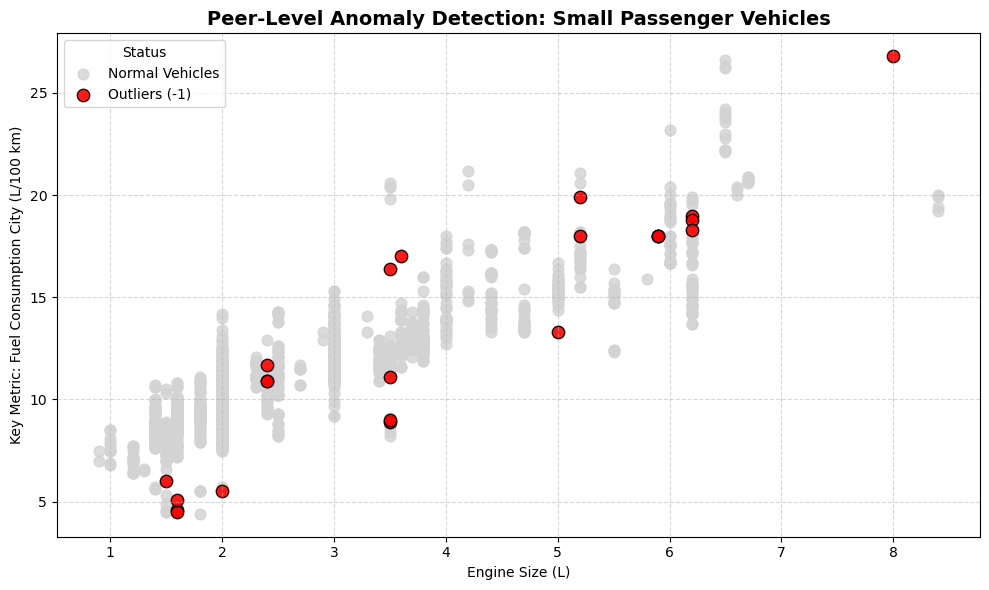


[Extreme Value Profile] Outliers in Small Passenger Vehicles:
A total of 23 outlier models were identified.

Outlier Group A: [Extreme Gas Guzzlers] (Top 5 Highest Fuel Consumption)
     Make                Model  Engine Size(L)  Cylinders Transmission Type Fuel Type  Fuel Consumption City (L/100 km)
  BUGATTI               CHIRON             8.0         16                AM         Z                              26.8
     FORD Shelby GT500 Mustang             5.2          8                AM         Z                              19.9
CHEVROLET           CAMARO ZL1             6.2          8                AS         Z                              19.0
CHEVROLET           CAMARO ZL1             6.2          8                AS         Z                              18.8
CHEVROLET           Camaro ZL1             6.2          8                AS         Z                              18.3

Outlier Group B: [Ultra-Efficient Anomalies] (Top 5 Lowest Fuel Consumption)
 Make        Model 

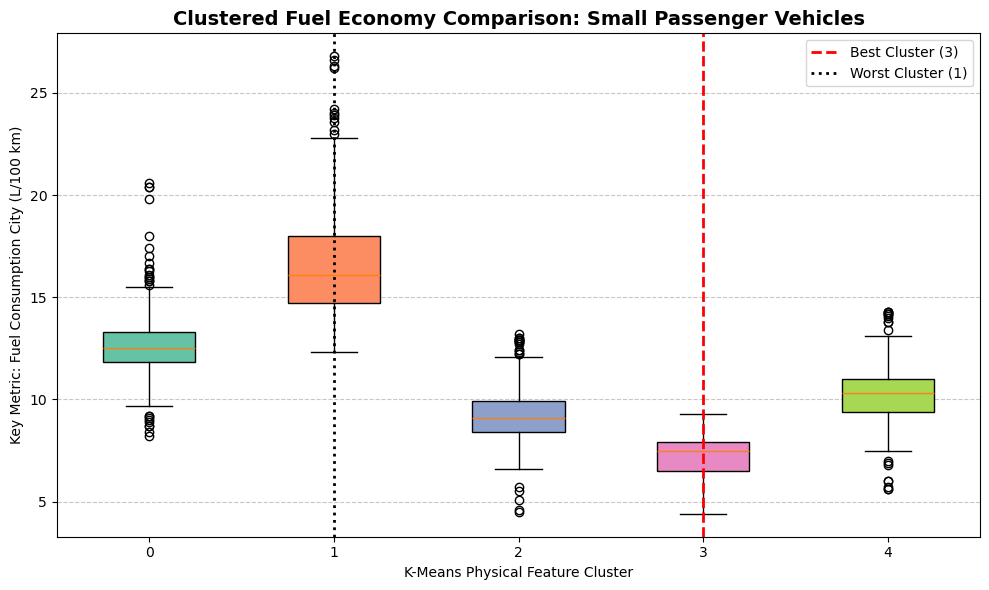


[Architecture Anatomy] Detailed feature comparison of [Best vs. Worst Cluster] for Small Passenger Vehicles:

[Optimal Fuel-Efficient Cluster - Cluster 3] Architecture Profile:
 - City Fuel Consumption (L/100 km): 7.22
 - HWY Fuel Consumption (L/100 km):  6.07
 - Comb Fuel Consumption (L/100 km): 6.71
 - Gears:                            0.00
 - Engine Size (L):                  1.60
 - Cylinders:                        3.87
 - Transmission Type:                100.0% AV
 - Fuel Type:                        96.2% X, 3.8% Z

[Worst Gas-Guzzling Cluster - Cluster 1] Architecture Profile:
 - City Fuel Consumption (L/100 km): 16.68
 - HWY Fuel Consumption (L/100 km):  10.85
 - Comb Fuel Consumption (L/100 km): 14.05
 - Gears:                            7.25
 - Engine Size (L):                  5.32
 - Cylinders:                        8.99
 - Transmission Type:                48.4% AS, 18.0% M, 17.6% A
 - Fuel Type:                        93.1% Z, 6.9% X


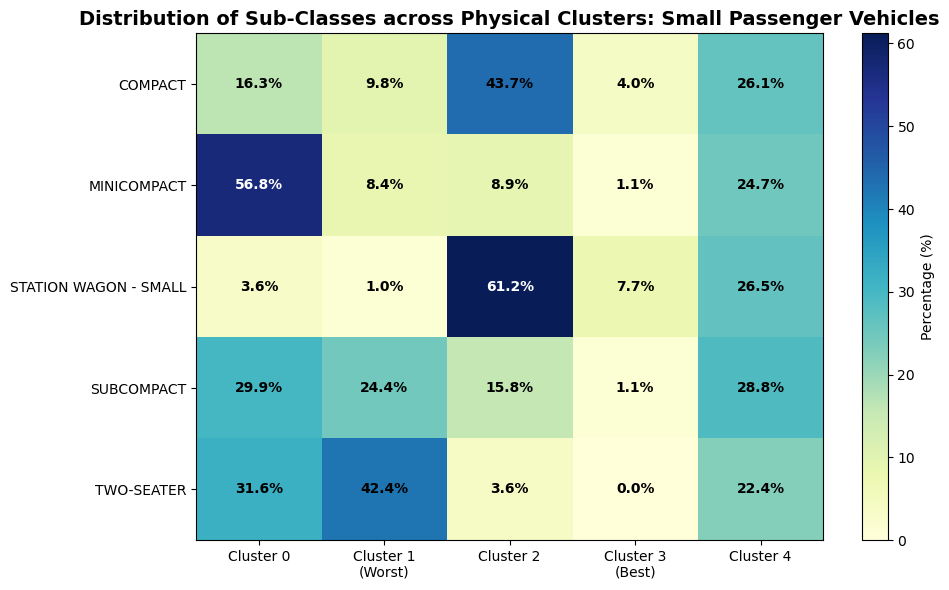


Comprehensive Analysis Case: Midsize & Large Passenger Vehicles



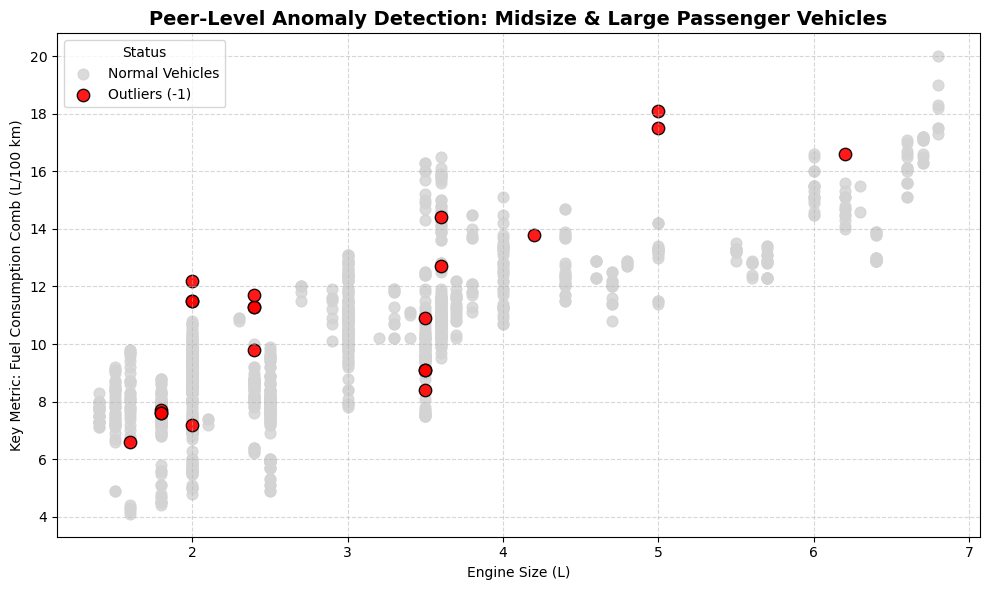


[Extreme Value Profile] Outliers in Midsize & Large Passenger Vehicles:
A total of 22 outlier models were identified.

Outlier Group A: [Extreme Gas Guzzlers] (Top 5 Highest Fuel Consumption)
    Make           Model  Engine Size(L)  Cylinders Transmission Type Fuel Type  Fuel Consumption Comb (L/100 km)
  JAGUAR             XFR             5.0          8                AS         E                              18.1
  JAGUAR XJ SUPERCHARGED             5.0          8                AS         E                              17.5
CADILLAC     CTS-V COUPE             6.2          8                AS         Z                              16.6
CHRYSLER   200 SEDAN FFV             3.6          6                 A         E                              14.4
CADILLAC         CT6 AWD             4.2          8                AS         Z                              13.8

Outlier Group B: [Ultra-Efficient Anomalies] (Top 5 Lowest Fuel Consumption)
     Make                  Model  Engine Size

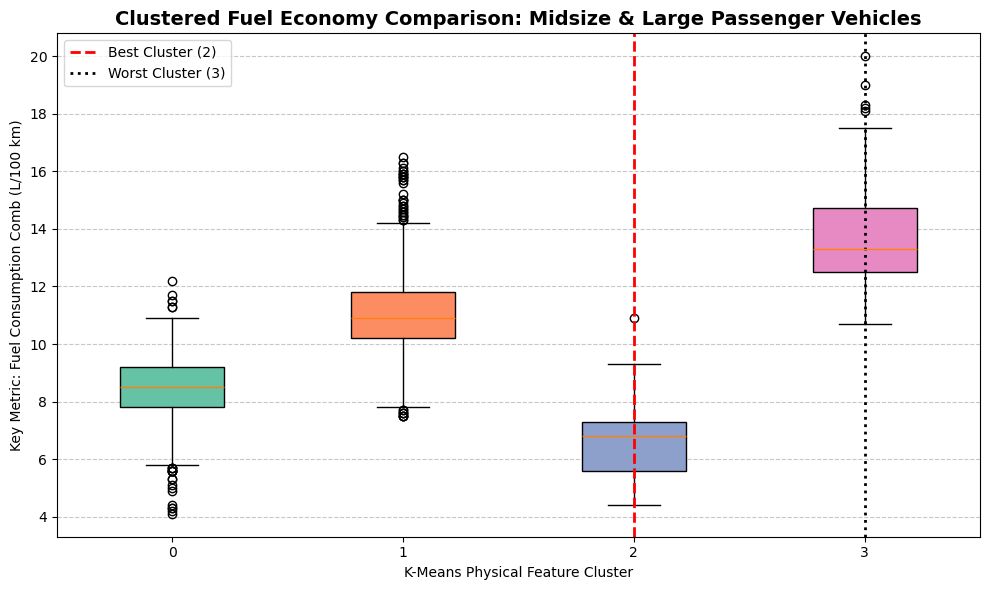


[Architecture Anatomy] Detailed feature comparison of [Best vs. Worst Cluster] for Midsize & Large Passenger Vehicles:

[Optimal Fuel-Efficient Cluster - Cluster 2] Architecture Profile:
 - City Fuel Consumption (L/100 km): 6.92
 - HWY Fuel Consumption (L/100 km):  5.96
 - Comb Fuel Consumption (L/100 km): 6.49
 - Gears:                            0.00
 - Engine Size (L):                  2.04
 - Cylinders:                        4.06
 - Transmission Type:                100.0% AV
 - Fuel Type:                        99.0% X, 1.0% Z

[Worst Gas-Guzzling Cluster - Cluster 3] Architecture Profile:
 - City Fuel Consumption (L/100 km): 16.40
 - HWY Fuel Consumption (L/100 km):  10.51
 - Comb Fuel Consumption (L/100 km): 13.75
 - Gears:                            7.60
 - Engine Size (L):                  5.28
 - Cylinders:                        8.77
 - Transmission Type:                61.4% AS, 24.1% A, 7.5% AM
 - Fuel Type:                        91.7% Z, 7.5% X, 0.9% E


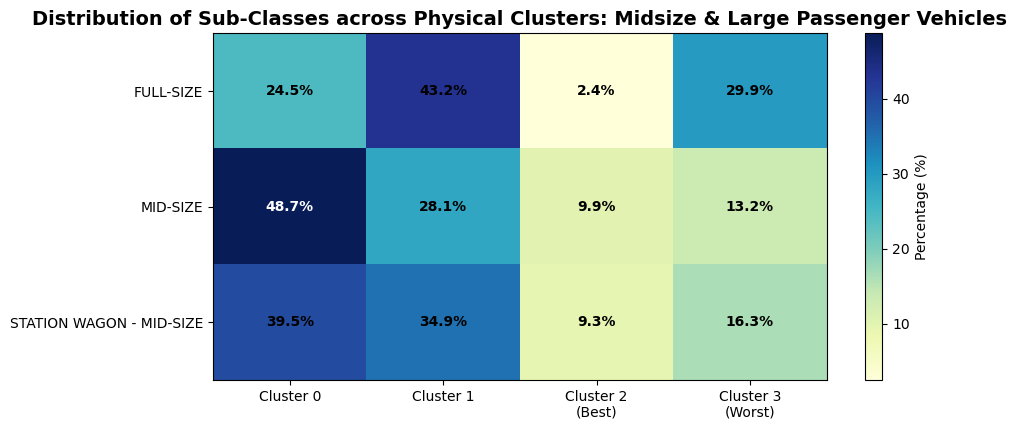


Comprehensive Analysis Case: SUVs & Minivans



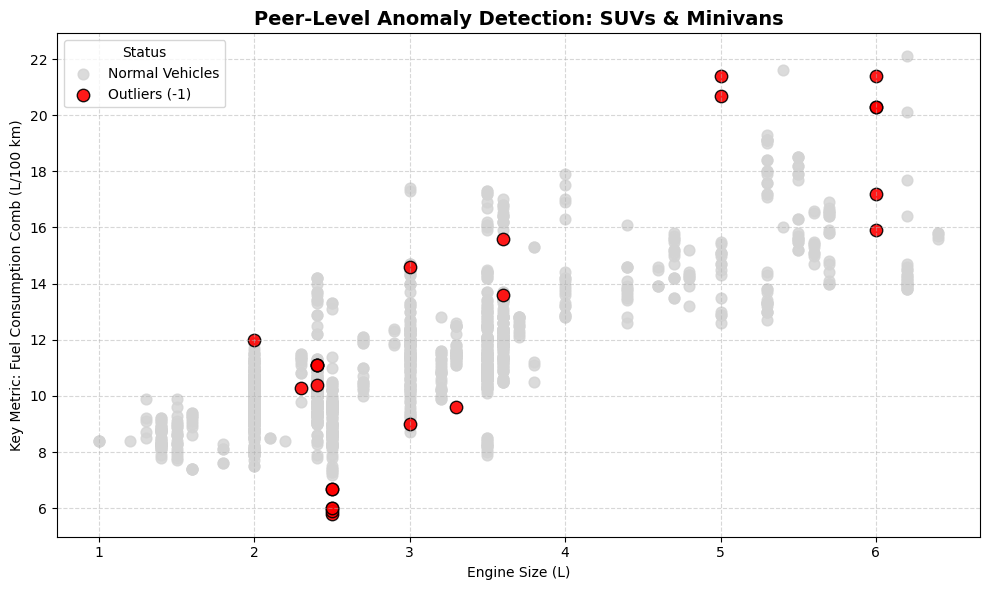


[Extreme Value Profile] Outliers in SUVs & Minivans:
A total of 24 outlier models were identified.

Outlier Group A: [Extreme Gas Guzzlers] (Top 5 Highest Fuel Consumption)
         Make                           Model  Engine Size(L)  Cylinders Transmission Type Fuel Type  Fuel Consumption Comb (L/100 km)
   LAND ROVER   RANGE ROVER LWB V8 5.0 SC FFV             5.0          8                AS         E                              21.4
MERCEDES-BENZ                        AMG G 65             6.0         12                AS         Z                              21.4
   LAND ROVER RANGE ROVER SPORT V8 5.0 SC FFV             5.0          8                AS         E                              20.7
MERCEDES-BENZ                        AMG G 65             6.0         12                AS         Z                              20.3
MERCEDES-BENZ                        AMG G 65             6.0         12                 A         Z                              20.3

Outlier Group B

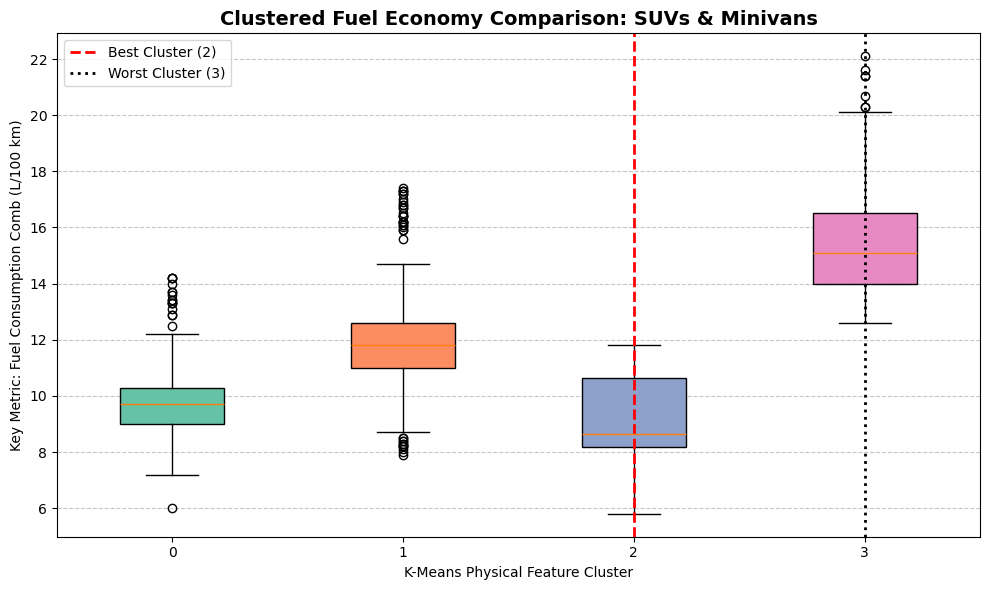


[Architecture Anatomy] Detailed feature comparison of [Best vs. Worst Cluster] for SUVs & Minivans:

[Optimal Fuel-Efficient Cluster - Cluster 2] Architecture Profile:
 - City Fuel Consumption (L/100 km): 10.03
 - HWY Fuel Consumption (L/100 km):  8.02
 - Comb Fuel Consumption (L/100 km): 9.13
 - Gears:                            0.00
 - Engine Size (L):                  2.64
 - Cylinders:                        4.62
 - Transmission Type:                100.0% AV
 - Fuel Type:                        94.6% X, 5.4% Z

[Worst Gas-Guzzling Cluster - Cluster 3] Architecture Profile:
 - City Fuel Consumption (L/100 km): 17.73
 - HWY Fuel Consumption (L/100 km):  12.78
 - Comb Fuel Consumption (L/100 km): 15.50
 - Gears:                            7.27
 - Engine Size (L):                  5.27
 - Cylinders:                        8.11
 - Transmission Type:                53.1% A, 46.9% AS
 - Fuel Type:                        70.4% Z, 17.9% X, 11.7% E


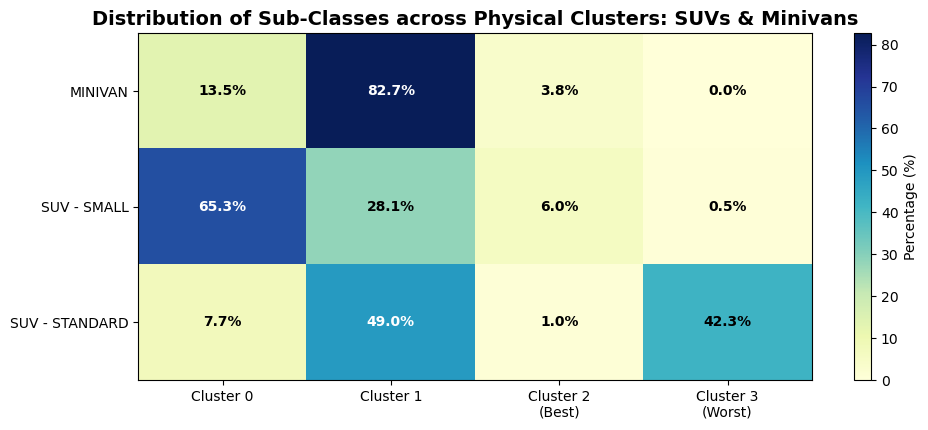


Comprehensive Analysis Case: Trucks, Vans & Specialty Utility



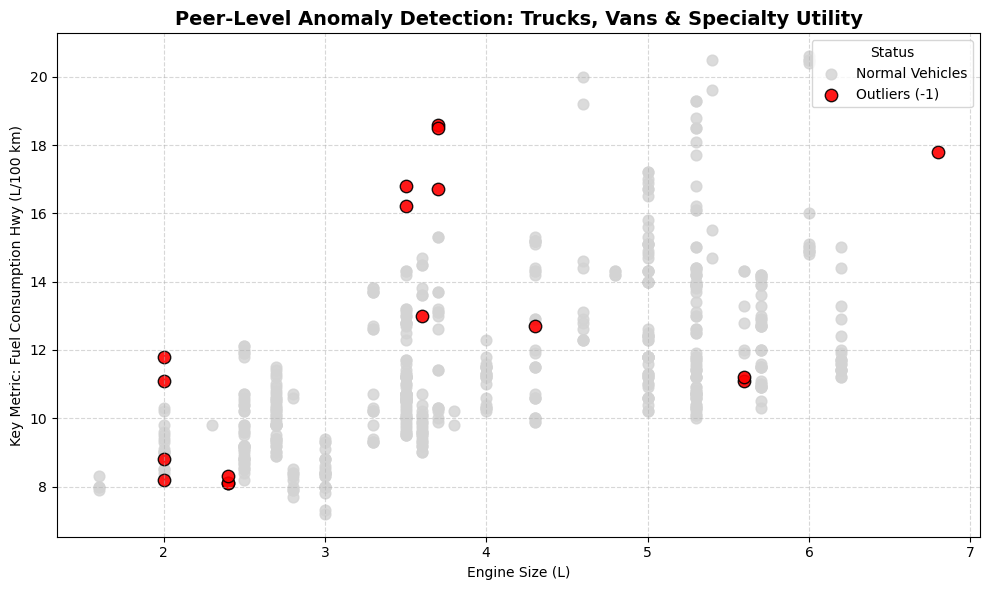


[Extreme Value Profile] Outliers in Trucks, Vans & Specialty Utility:
A total of 17 outlier models were identified.

Outlier Group A: [Extreme Gas Guzzlers] (Top 5 Highest Fuel Consumption)
Make               Model  Engine Size(L)  Cylinders Transmission Type Fuel Type  Fuel Consumption Hwy (L/100 km)
FORD     T-150 WAGON FFV             3.7          6                AS         E                             18.6
FORD     T-150 WAGON FFV             3.7          6                AS         E                             18.5
FORD          E350 WAGON             6.8         10                 A         X                             17.8
FORD T-150 Wagon FFV 4WD             3.5          6                AS         E                             16.8
FORD     T-150 WAGON FFV             3.7          6                AS         E                             16.7

Outlier Group B: [Ultra-Efficient Anomalies] (Top 5 Lowest Fuel Consumption)
Make                     Model  Engine Size(L)  Cylin

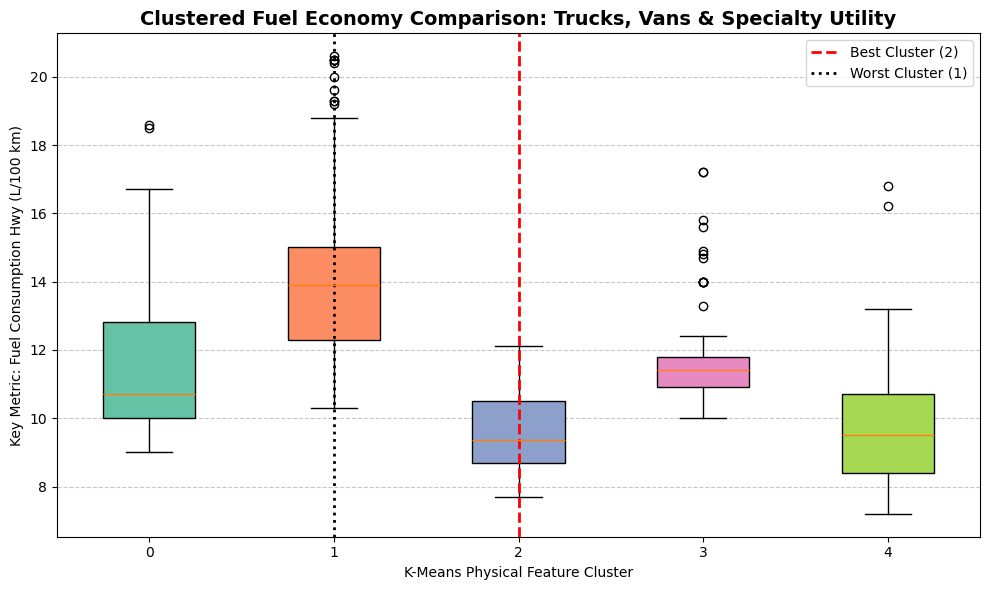


[Architecture Anatomy] Detailed feature comparison of [Best vs. Worst Cluster] for Trucks, Vans & Specialty Utility:

[Optimal Fuel-Efficient Cluster - Cluster 2] Architecture Profile:
 - City Fuel Consumption (L/100 km): 12.27
 - HWY Fuel Consumption (L/100 km):  9.60
 - Comb Fuel Consumption (L/100 km): 11.06
 - Gears:                            5.72
 - Engine Size (L):                  2.43
 - Cylinders:                        4.00
 - Transmission Type:                42.4% A, 39.1% AS, 13.0% M
 - Fuel Type:                        71.7% X, 12.0% D, 8.7% E

[Worst Gas-Guzzling Cluster - Cluster 1] Architecture Profile:
 - City Fuel Consumption (L/100 km): 19.20
 - HWY Fuel Consumption (L/100 km):  14.02
 - Comb Fuel Consumption (L/100 km): 16.87
 - Gears:                            5.73
 - Engine Size (L):                  5.35
 - Cylinders:                        8.01
 - Transmission Type:                65.3% A, 34.7% AS
 - Fuel Type:                        66.7% X, 31.9% E, 1.4% 

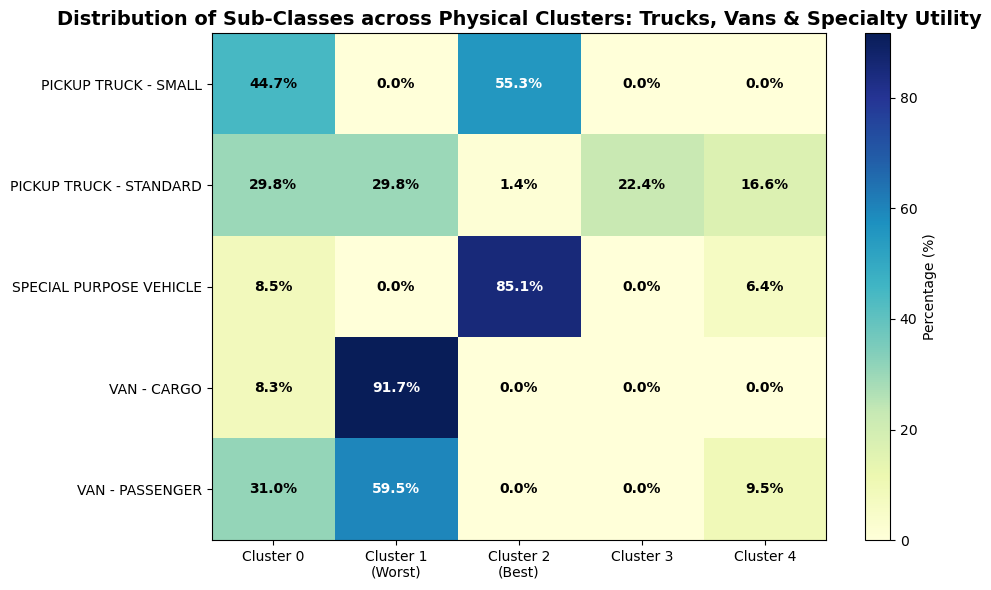

In [10]:
# ==========================================
# Phase 4: Segmented Visualizations & Deep Dive Analysis
# ==========================================
target_metric_map = {
    'Small Passenger Vehicles': 'Fuel Consumption City (L/100 km)',
    'Midsize & Large Passenger Vehicles': 'Fuel Consumption Comb (L/100 km)',
    'SUVs & Minivans': 'Fuel Consumption Comb (L/100 km)',
    'Trucks, Vans & Specialty Utility': 'Fuel Consumption Hwy (L/100 km)'
}

def plot_segment_outliers(segment_name):
    subset = df_results[df_results['Macro_Class'] == segment_name]
    normal_pts = subset[subset['DBSCAN_Cluster'] != -1]
    outlier_pts = subset[subset['DBSCAN_Cluster'] == -1]
    target_metric = target_metric_map.get(segment_name, 'Fuel Consumption Comb (L/100 km)')
    
    plt.figure(figsize=(10, 6))
    plt.scatter(normal_pts['Engine Size(L)'], normal_pts[target_metric], 
                c='lightgray', label='Normal Vehicles', alpha=0.8, s=60)
    plt.scatter(outlier_pts['Engine Size(L)'], outlier_pts[target_metric], 
                c='red', label='Outliers (-1)', alpha=0.9, s=80, edgecolors='black')
    
    plt.title(f'Peer-Level Anomaly Detection: {segment_name}', fontweight='bold', fontsize=14)
    plt.xlabel('Engine Size (L)')
    plt.ylabel(f'Key Metric: {target_metric}')
    plt.legend(title='Status')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    #  Restore: print the exact Make and Model for each outlier
    print(f"\n[Extreme Value Profile] Outliers in {segment_name}:")
    if len(outlier_pts) > 0:
        display_cols = ['Make', 'Model', 'Engine Size(L)', 'Cylinders', 'Transmission Type', 'Fuel Type', target_metric]
        outliers_sorted = outlier_pts.sort_values(by=target_metric, ascending=False)
        print(f"A total of {len(outlier_pts)} outlier models were identified.")
        print("\nOutlier Group A: [Extreme Gas Guzzlers] (Top 5 Highest Fuel Consumption)")
        print(outliers_sorted.head(5)[display_cols].to_string(index=False))
        if len(outlier_pts) > 5:
            print("\nOutlier Group B: [Ultra-Efficient Anomalies] (Top 5 Lowest Fuel Consumption)")
            print(outliers_sorted.tail(5)[display_cols].to_string(index=False))
    else:
        print("Conclusion: Vehicle designs in this category are highly consistent; no significant anomalies were detected.")

def plot_segment_clusters(segment_name):
    subset = df_results[df_results['Macro_Class'] == segment_name]
    target_metric = target_metric_map.get(segment_name, 'Fuel Consumption Comb (L/100 km)')
    
    cluster_stats_metric = subset.groupby('KMeans_Cluster')[[target_metric]].mean()
    best_cluster_idx = cluster_stats_metric[target_metric].idxmin()
    worst_cluster_idx = cluster_stats_metric[target_metric].idxmax()
    
    clusters = sorted(subset['KMeans_Cluster'].unique())
    data_to_plot = [subset[subset['KMeans_Cluster'] == c][target_metric] for c in clusters]
    
    plt.figure(figsize=(10, 6))
    box = plt.boxplot(data_to_plot, labels=clusters, patch_artist=True)
    colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']
    for patch, color in zip(box['boxes'], colors[:len(clusters)]):
        patch.set_facecolor(color)
        
    plt.axvline(x=clusters.index(best_cluster_idx) + 1, color='red', linestyle='--', linewidth=2, label=f'Best Cluster ({best_cluster_idx})')
    plt.axvline(x=clusters.index(worst_cluster_idx) + 1, color='black', linestyle=':', linewidth=2, label=f'Worst Cluster ({worst_cluster_idx})')
    
    plt.title(f'Clustered Fuel Economy Comparison: {segment_name}', fontweight='bold', fontsize=14)
    plt.xlabel('K-Means Physical Feature Cluster')
    plt.ylabel(f'Key Metric: {target_metric}')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"\n[Architecture Anatomy] Detailed feature comparison of [Best vs. Worst Cluster] for {segment_name}:")
    
    best_df = subset[subset['KMeans_Cluster'] == best_cluster_idx]
    worst_df = subset[subset['KMeans_Cluster'] == worst_cluster_idx]
    
    def get_top_categories(series):
        vc = series.value_counts(normalize=True) * 100
        parts = [f"{pct:.1f}% {val}" for val, pct in vc.head(3).items()]
        return ", ".join(parts)

    def print_cluster_profile(df_cluster, cluster_type, cluster_idx):
        city_fuel = df_cluster['Fuel Consumption City (L/100 km)'].mean()
        hwy_fuel = df_cluster['Fuel Consumption Hwy (L/100 km)'].mean()
        comb_fuel = df_cluster['Fuel Consumption Comb (L/100 km)'].mean()
        gears = df_cluster['Gear num'].mean()
        engine = df_cluster['Engine Size(L)'].mean()
        cylinders = df_cluster['Cylinders'].mean()
        
        print(f"\n[{cluster_type} - Cluster {cluster_idx}] Architecture Profile:")
        print(f" - City Fuel Consumption (L/100 km): {city_fuel:.2f}")
        print(f" - HWY Fuel Consumption (L/100 km):  {hwy_fuel:.2f}")
        print(f" - Comb Fuel Consumption (L/100 km): {comb_fuel:.2f}")
        print(f" - Gears:                            {gears:.2f}")
        print(f" - Engine Size (L):                  {engine:.2f}")
        print(f" - Cylinders:                        {cylinders:.2f}")
        print(f" - Transmission Type:                {get_top_categories(df_cluster['Transmission Type'])}")
        print(f" - Fuel Type:                        {get_top_categories(df_cluster['Fuel Type'])}")

    print_cluster_profile(best_df, "Optimal Fuel-Efficient Cluster", best_cluster_idx)
    print_cluster_profile(worst_df, "Worst Gas-Guzzling Cluster", worst_cluster_idx)


def plot_segment_distribution(segment_name):
    subset = df_results[df_results['Macro_Class'] == segment_name]
    target_metric = target_metric_map.get(segment_name, 'Fuel Consumption Comb (L/100 km)')
    
    cluster_stats_metric = subset.groupby('KMeans_Cluster')[[target_metric]].mean()
    best_idx = cluster_stats_metric[target_metric].idxmin()
    worst_idx = cluster_stats_metric[target_metric].idxmax()
    
    crosstab_pct = pd.crosstab(subset['Vehicle Class'], subset['KMeans_Cluster'], normalize='index') * 100
    
    fig, ax = plt.subplots(figsize=(10, len(crosstab_pct)*0.8 + 2))
    cax = ax.imshow(crosstab_pct.values, cmap="YlGnBu", aspect='auto')
    
    ax.set_xticks(np.arange(len(crosstab_pct.columns)))
    ax.set_yticks(np.arange(len(crosstab_pct.index)))
    
    x_labels = []
    for c in crosstab_pct.columns:
        if c == best_idx: x_labels.append(f"Cluster {c}\n(Best)")
        elif c == worst_idx: x_labels.append(f"Cluster {c}\n(Worst)")
        else: x_labels.append(f"Cluster {c}")
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(crosstab_pct.index)
    
    for i in range(len(crosstab_pct.index)):
        for j in range(len(crosstab_pct.columns)):
            val = crosstab_pct.values[i, j]
            text_color = "white" if val > 45 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", color=text_color, fontweight='bold')
            
    plt.title(f'Distribution of Sub-Classes across Physical Clusters: {segment_name}', fontweight='bold', fontsize=14)
    fig.colorbar(cax, ax=ax).set_label('Percentage (%)')
    plt.tight_layout()
    plt.show()

# ==========================================
# Final Interactive Analysis Demonstration (Auto-loop through 4 segments)
# ==========================================
for segment in target_metric_map.keys():
    print("\n" + "="*80)
    print(f"Comprehensive Analysis Case: {segment}")
    print("="*80 + "\n")
    
    plot_segment_outliers(segment)
    plot_segment_clusters(segment)
    plot_segment_distribution(segment)

# Data-Driven Vehicle Architecture & Emission Reduction Strategy Report
# Imperial College London — Data Engineering Final Project

---

## 1. Executive Summary

This study presents a rigorous, data-driven analysis of the Canadian light-duty vehicle fleet, employing a **Dual-Track Unsupervised Learning** framework to decode the latent relationship between powertrain architecture and fuel-economy performance. The pipeline ingests **7,385 raw emission records** from the Government of Canada's official registry, refines them through deduplication and quality filtering into **4,932 validated observations**, and enriches the clean dataset via deterministic Left Join to recover the original manufacturer (`Make`) and model (`Model`) identifiers — a critical step that ensures every anomaly detected can be traced back to a real-world production vehicle.

**The Dual-Track Design Philosophy:**

- **Track A — K-Means "Blind Box" Clustering:** Physical architecture features only (Engine Size, Cylinders, Gear Count, Transmission Type, Fuel Type) are fed into K-Means, with all fuel-consumption metrics deliberately excluded. This forces the algorithm to discover vehicle "body plans" purely from mechanical DNA, without the circular influence of the performance outcome variable. The best and worst clusters are then *post-hoc* evaluated against the segment-specific fuel-economy KPI, revealing which physical configurations are inherently efficient or wasteful — a causal insight that a consumption-inclusive clustering would conflate.

- **Track B — DBSCAN Full-Dimensional Anomaly Detection:** All numerical features including fuel consumption are standardized and passed to DBSCAN (ε=1.6, min_samples=4). Observations flagged as noise (Cluster = –1) represent vehicles whose combined physical + performance profiles are statistically incompatible with any dense neighbourhood — i.e., they are the genuine "black-tech" ultra-efficient outliers or the "condemned" extreme gas guzzlers.

The fleet is stratified into **four macro-classes** — Small Passenger Vehicles, Midsize & Large Passenger Vehicles, SUVs & Minivans, and Trucks/Vans/Specialty Utility — each assigned a KPI aligned with its dominant use case: City consumption for urban commuters, Combined for mixed-use segments, and Highway for logistics platforms. All scaling, clustering, and anomaly detection are performed **independently within each macro-class**, ensuring that a compact hatchback is never benchmarked against a full-size pickup.

**Key Findings at a Glance:**
1. Across three of four passenger-oriented segments, the optimal physical cluster is defined by a **100% CVT/e-CVT (AV) transmission** architecture — a finding that would be impossible to observe if fuel consumption were included in the clustering features.
2. The commercial truck segment is the sole exception: its optimal cluster favours **conventional automatics and manuals (0% CVT)**, reflecting payload-durability constraints.
3. DBSCAN anomaly detection reveals that **E85 Flex-Fuel (Fuel Type E)** is a hidden volumetric efficiency liability, consistently placing vehicles among the worst outliers in Midsize, SUV, and Truck segments — even when engine displacement is moderate.
4. Hybrid-electric e-CVT platforms (Toyota RAV4 Hybrid, Ford Escape Hybrid, KIA Niro) achieve **35–40% consumption reduction** versus the optimal conventional cluster in their respective segments, establishing hybridization as the definitive next-generation architecture for high-mass platforms.

---

## 2. Category Deep Dives

### 2.1 Segment A: Small Passenger Vehicles

**Segment KPI:** City Fuel Consumption (L/100 km)
**K-Means Configuration:** K = 5 clusters | **DBSCAN Anomalies Detected:** 23

#### 2.1.1 K-Means Track A — Optimal Physical Architecture (Cluster 3)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **1.60 L** |
| Mean Cylinder Count | **3.87** |
| Gear Count | **0.00** (no discrete gear steps) |
| Transmission Type | **100.0% AV** (CVT / e-CVT) |
| Fuel Type | **96.2% X** (Regular Gasoline), 3.8% Z (Premium) |
| City Fuel Consumption | **7.22 L/100km** |
| Highway Fuel Consumption | 6.07 L/100km |
| Combined Fuel Consumption | 6.71 L/100km |

**Engineering Interpretation:** The mean cylinder count of 3.87 reveals a cluster that is not monolithically four-cylinder, but incorporates a minor contingent of advanced 3-cylinder downsized engines (e.g., 1.0L Ford EcoBoost-class turbocharged triples). The universal CVT adoption (100% AV, zero discrete gears) is the single most powerful discriminator of efficiency: by eliminating torque-converter losses and maintaining the engine at its optimal BSFC (Brake-Specific Fuel Consumption) island across the urban speed envelope, the CVT architecture achieves a 57% city-consumption advantage over the worst cluster. The 96.2% Regular Gasoline dominance further signals that this efficient architecture does not depend on high-octane fuel — it is a mass-market solution.

#### 2.1.2 K-Means Track A — Worst Physical Architecture (Cluster 1)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **5.32 L** |
| Mean Cylinder Count | **8.99** |
| Gear Count | **7.25** |
| Transmission Type | **48.4% AS**, 18.0% M, 17.6% A |
| Fuel Type | **93.1% Z** (Premium Gasoline), 6.9% X |
| City Fuel Consumption | **16.68 L/100km** |

**Engineering Interpretation:** This cluster represents performance-oriented sports cars and grand tourers classified under small vehicle sub-classes (e.g., TWO-SEATER, SUBCOMPACT). The 5.32L / 9-cylinder mean with 93% Premium fuel consumption indicates large-displacement naturally-aspirated or supercharged V8/V10 architectures. The heterogeneous transmission mix (AS/M/A) reflects the performance segment's preference for stepped automatics and manuals that provide driver engagement at the cost of thermodynamic optimality. At **16.68 L/100km**, this cluster consumes **2.31×** the best — the widest best-to-worst ratio of any segment.

#### 2.1.3 DBSCAN Track B — Anomaly Analysis

**Ultra-Efficient Anomalies (Top 5 Lowest City Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | City (L/100km) |
|---|---|---|---|---|---|---|
| KIA | **NIRO FE** | 1.6L | 4 | AM | X | **4.5** |
| KIA | **NIRO** | 1.6L | 4 | AM | X | **4.6** |
| KIA | **NIRO TOURING** | 1.6L | 4 | AM | X | **5.1** |
| LEXUS | **UX 250h** | 2.0L | 4 | AV | X | **5.5** |
| ACURA | **ILX HYBRID** | 1.5L | 4 | AV | Z | **6.0** |

**Black-Tech Insight:** The KIA Niro family dominates the ultra-efficient frontier with a unified architecture: 1.6L Atkinson-cycle 4-cylinder + Dual-Clutch Automated Manual (AM/DCT) + Hybrid Fuel Type X. The AM transmission code here denotes a 6-speed DCT integrated with an electric motor — a parallel hybrid topology distinct from the power-split e-CVT used by Toyota/Lexus. At 4.5 L/100km, the Niro FE achieves **37.7% lower consumption** than even the best K-Means cluster mean, confirming that hybridization pushes efficiency into a regime physically unreachable by any conventional ICE+CVT combination. The Lexus UX 250h (2.0L/AV) represents Toyota's e-CVT hybrid architecture in this segment, while the Acura ILX Hybrid (1.5L/AV) demonstrates Honda's i-MMD (Intelligent Multi-Mode Drive) system.

**Extreme Gas Guzzlers (Top 5 Highest City Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | City (L/100km) |
|---|---|---|---|---|---|---|
| BUGATTI | **CHIRON** | 8.0L | 16 | AM | Z | **26.8** |
| FORD | **Shelby GT500 Mustang** | 5.2L | 8 | AM | Z | **19.9** |
| CHEVROLET | **CAMARO ZL1** | 6.2L | 8 | AS | Z | **19.0** |
| CHEVROLET | **CAMARO ZL1** | 6.2L | 8 | AS | Z | **18.8** |
| CHEVROLET | **Camaro ZL1** | 6.2L | 8 | AS | Z | **18.3** |

**Condemned-Tech Insight:** The Bugatti Chiron's quad-turbo 8.0L W16 at 26.8 L/100km represents an engineering singularity — consuming **3.71×** the best cluster and **5.96×** the best anomaly. The Shelby GT500's supercharged 5.2L "Predator" V8 and the Camaro ZL1's supercharged 6.2L LT4 V8 form a cohort of American muscle platforms whose thermodynamic profiles are irreconcilable with any plausible urban emissions mandate.

---

### 2.2 Segment B: Midsize & Large Passenger Vehicles

**Segment KPI:** Combined Fuel Consumption (L/100 km)
**K-Means Configuration:** K = 4 clusters | **DBSCAN Anomalies Detected:** 22

#### 2.2.1 K-Means Track A — Optimal Physical Architecture (Cluster 2)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **2.04 L** |
| Mean Cylinder Count | **4.06** |
| Gear Count | **0.00** |
| Transmission Type | **100.0% AV** |
| Fuel Type | **99.0% X**, 1.0% Z |
| Combined Fuel Consumption | **6.49 L/100km** |
| City / Highway | 6.92 / 5.96 L/100km |

**Engineering Interpretation:** This cluster demonstrates that the CVT efficiency advantage scales seamlessly to larger platforms. Despite increased curb weight, the 2.04L / 4-cylinder / 100% AV architecture achieves 6.49 L/100km Combined — only 0.22 L/100km less efficient than the small-vehicle optimal cluster in Highway consumption. The 99.0% Regular Gasoline prevalence confirms mass-market accessibility. The zero gear count is structurally diagnostic of e-CVT hybrid or planetary CVT systems, which avoid the parasitic drag of a traditional torque converter.

#### 2.2.2 K-Means Track A — Worst Physical Architecture (Cluster 3)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **5.28 L** |
| Mean Cylinder Count | **8.77** |
| Gear Count | **7.60** |
| Transmission Type | **61.4% AS**, 24.1% A, 7.5% AM |
| Fuel Type | **91.7% Z**, 7.5% X, 0.9% E |
| Combined Fuel Consumption | **13.75 L/100km** |

**Engineering Interpretation:** The 5.28L / 8.77-cylinder profile represents the legacy luxury-performance sedan archetype (e.g., large-displacement V8 executive saloons). The 61.4% AS (Automatic with Select Shift) dominance reflects the sport-luxury market's emphasis on paddle-shift capability. At **2.12×** the optimal, this cluster's consumption profile faces direct regulatory exposure under Canada's Passenger Automobile and Light Truck Greenhouse Gas Emission Regulations.

#### 2.2.3 DBSCAN Track B — Anomaly Analysis

**Ultra-Efficient Anomalies (Top 5 Lowest Combined Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Comb (L/100km) |
|---|---|---|---|---|---|---|
| CHEVROLET | **CRUZE HATCHBACK DIESEL** | 1.6L | 4 | A | D | **6.6** |
| LEXUS | **UX 200** | 2.0L | 4 | AS | X | **7.2** |
| TOYOTA | **COROLLA** | 1.8L | 4 | A | X | **7.6** |
| TOYOTA | **COROLLA** | 1.8L | 4 | A | X | **7.6** |
| TOYOTA | **COROLLA** | 1.8L | 4 | A | X | **7.7** |

**Black-Tech Insight:** The segment champion is the **Chevrolet Cruze Hatchback Diesel** — the only Diesel (Fuel Type D) anomaly across all four segments. Its 1.6L turbodiesel direct-injection engine achieves **6.6 L/100km Combined**, marginally surpassing the best K-Means cluster mean (6.49) while using a conventional automatic rather than CVT. This finding validates a distinct efficiency pathway: high-compression-ratio diesel combustion with common-rail injection can rival hybrid-CVT architectures in combined-cycle performance, particularly at highway-biased operating points where diesel's thermodynamic advantage is maximised. The Toyota Corolla Hybrid variants (1.8L, Fuel Type X) at 7.6–7.7 L/100km confirm Atkinson-cycle + e-CVT as the dominant gasoline-hybrid benchmark.

**Extreme Gas Guzzlers (Top 5 Highest Combined Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Comb (L/100km) |
|---|---|---|---|---|---|---|
| JAGUAR | **XFR** | 5.0L | 8 | AS | E | **18.1** |
| JAGUAR | **XJ SUPERCHARGED** | 5.0L | 8 | AS | E | **17.5** |
| CADILLAC | **CTS-V COUPE** | 6.2L | 8 | AS | Z | **16.6** |
| CHRYSLER | **200 SEDAN FFV** | 3.6L | 6 | A | E | **14.4** |
| CADILLAC | **CT6 AWD** | 4.2L | 8 | AS | Z | **13.8** |

**Condemned-Tech Insight:** A critical and novel observation: the two worst performers (Jaguar XFR and XJ Supercharged) are powered by identical 5.0L supercharged V8 engines, yet their extreme 18.1 and 17.5 L/100km figures are substantially inflated by **E85 Ethanol (Fuel Type E)**, not merely by displacement alone. E85's volumetric energy density is approximately 27% lower than gasoline, meaning these vehicles must inject roughly 37% more fuel by volume to produce equivalent power — a penalty that compounds with the already-high base consumption of a supercharged V8. The Chrysler 200 Sedan FFV (3.6L V6, E85) at 14.4 L/100km is a particularly instructive case: a *midsize sedan* with only 6 cylinders consuming more than many full-size SUVs, solely because of the E85 fuel penalty. This establishes **E85 as an independent efficiency liability**, distinct from — and additive to — the displacement/cylinder-count penalty.

---

### 2.3 Segment C: SUVs & Minivans

**Segment KPI:** Combined Fuel Consumption (L/100 km)
**K-Means Configuration:** K = 4 clusters | **DBSCAN Anomalies Detected:** 24

#### 2.3.1 K-Means Track A — Optimal Physical Architecture (Cluster 2)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **2.64 L** |
| Mean Cylinder Count | **4.62** |
| Gear Count | **0.00** |
| Transmission Type | **100.0% AV** |
| Fuel Type | **94.6% X**, 5.4% Z |
| Combined Fuel Consumption | **9.13 L/100km** |
| City / Highway | 10.03 / 8.02 L/100km |

**Engineering Interpretation:** The 2.64L mean displacement — the highest among optimal clusters — reflects the SUV segment's structural need for more torque to overcome greater curb weight and aerodynamic drag (Cd × A). Yet the architecture remains anchored in **100% CVT/e-CVT** with zero gear steps, confirming that the power-split e-CVT topology (as implemented by Toyota's THS-II and Ford's PowerSplit) scales effectively to crossover and SUV platforms. The mean cylinder count of 4.62 suggests a blend of inline-4 and a small proportion of V6 hybrid configurations. Critically, this cluster achieves **9.13 L/100km Combined** — competitive with many conventional compact sedans — purely through architectural optimisation.

#### 2.3.2 K-Means Track A — Worst Physical Architecture (Cluster 3)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **5.27 L** |
| Mean Cylinder Count | **8.11** |
| Gear Count | **7.27** |
| Transmission Type | **53.1% A**, 46.9% AS |
| Fuel Type | **70.4% Z**, 17.9% X, **11.7% E** |
| Combined Fuel Consumption | **15.50 L/100km** |

**Engineering Interpretation:** This cluster exhibits the most diverse fuel-type profile of any worst cluster: 70.4% Premium (Z), 17.9% Regular (X), and a notable **11.7% E85 Ethanol (E)**. The ethanol share — the highest of any segment's worst cluster — compounds the already-severe displacement penalty. The 53.1% A / 46.9% AS transmission split suggests legacy body-on-frame full-size SUVs (e.g., Chevrolet Tahoe, GMC Yukon-class) that have not adopted modern sport-shift automatics. At **15.50 L/100km**, this cluster is **1.70×** the optimal.

#### 2.3.3 DBSCAN Track B — Anomaly Analysis

**Ultra-Efficient Anomalies (Top 5 Lowest Combined Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Comb (L/100km) |
|---|---|---|---|---|---|---|
| FORD | **Escape Hybrid** | 2.5L | 4 | AV | X | **5.8** |
| FORD | **Escape Hybrid AWD** | 2.5L | 4 | AV | X | **5.9** |
| TOYOTA | **RAV4 Hybrid AWD** | 2.5L | 4 | AV | X | **6.0** |
| TOYOTA | **RAV4 Hybrid AWD** | 2.5L | 4 | AV | X | **6.0** |
| TOYOTA | **Highlander Hybrid AWD** | 2.5L | 4 | AV | X | **6.7** |

**Black-Tech Insight:** This is the most architecturally coherent anomaly group in the entire study: **all five vehicles share an identical hardware signature — 2.5L 4-cylinder, AV (e-CVT), Fuel Type X (Hybrid)**. This architectural uniformity is not coincidence but convergent engineering optimisation: both Toyota (THS-II power-split planetary gear e-CVT) and Ford (PowerSplit hybrid transaxle) have independently converged on a 2.5L Atkinson-cycle inline-4 as the optimal displacement for SUV-class hybridisation. At **5.8 L/100km**, the Ford Escape Hybrid consumes **36.5% less** than the best K-Means cluster mean (9.13) — a reduction attributable entirely to the electric motor's regenerative braking energy recovery and low-speed EV mode, which the blind K-Means clustering (lacking consumption data) correctly classifies under the same AV-transmission physical archetype but cannot distinguish from non-hybrid CVTs.

The **Toyota Highlander Hybrid AWD** at 6.7 L/100km is particularly noteworthy: this is a three-row, 7-passenger mid-size SUV achieving fuel economy superior to most conventional compact sedans. It demonstrates that hybridisation has effectively decoupled vehicle utility/size from energy intensity — a paradigm shift with profound regulatory implications.

**Extreme Gas Guzzlers (Top 5 Highest Combined Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Comb (L/100km) |
|---|---|---|---|---|---|---|
| LAND ROVER | **RANGE ROVER LWB V8 5.0 SC FFV** | 5.0L | 8 | AS | E | **21.4** |
| MERCEDES-BENZ | **AMG G 65** | 6.0L | 12 | AS | Z | **21.4** |
| LAND ROVER | **RANGE ROVER SPORT V8 5.0 SC FFV** | 5.0L | 8 | AS | E | **20.7** |
| MERCEDES-BENZ | **AMG G 65** | 6.0L | 12 | AS | Z | **20.3** |
| MERCEDES-BENZ | **AMG G 65** | 6.0L | 12 | A | Z | **20.3** |

**Condemned-Tech Insight:** The co-leaders at 21.4 L/100km embody two distinct pathways to extreme inefficiency. The **Range Rover LWB FFV** (5.0L supercharged V8, E85 Ethanol) suffers a dual penalty: forced induction increases base consumption, and E85's lower energy density inflates volumetric fuel delivery by ~37%. The **Mercedes-Benz AMG G 65** (6.0L biturbo **V12**, Premium Gasoline) represents the last generation of civilian V12 SUVs — a 12-cylinder architecture whose frictional, thermal, and mass penalties are fundamentally irreconcilable with any foreseeable emissions standard. At **21.4 L/100km**, these platforms consume **3.69×** the best anomaly (Ford Escape Hybrid, 5.8) and **2.34×** the worst cluster mean (15.50) — making them outliers even among outliers.

---

### 2.4 Segment D: Trucks, Vans & Specialty Utility

**Segment KPI:** Highway Fuel Consumption (L/100 km)
**K-Means Configuration:** K = 5 clusters | **DBSCAN Anomalies Detected:** 17

#### 2.4.1 K-Means Track A — Optimal Physical Architecture (Cluster 2)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **2.43 L** |
| Mean Cylinder Count | **4.00** |
| Gear Count | **5.72** |
| Transmission Type | **42.4% A**, 39.1% AS, 13.0% M |
| Fuel Type | **71.7% X**, 12.0% D, 8.7% E |
| Highway Fuel Consumption | **9.60 L/100km** |
| City / Combined | 12.27 / 11.06 L/100km |

**Engineering Interpretation — The CVT Exception:** This is the **only optimal cluster across all four segments that does not feature CVT/AV transmission**. Instead, the mix is dominated by conventional automatics (42.4% A), automatic-with-select-shift (39.1% AS), and manual (13.0% M). The 5.72 mean gear count reflects 5- and 6-speed stepped gearboxes. This departure from the CVT paradigm has a clear engineering rationale: commercial truck and van platforms must sustain high torque loads under payload, towing, and frequent stop-start urban delivery cycles. Torque-converter automatics and robust manual transmissions offer superior heat dissipation and durability under these conditions; the belt-and-pulley CVT's torque capacity limitations make it mechanically unsuitable for this duty cycle.

The fuel-type diversity is also unique: **12.0% Diesel (D)** represents light commercial diesels (e.g., Ram EcoDiesel, Transit diesel variants) that exploit diesel's higher thermal efficiency for highway cruising. The 8.7% E85 presence reflects flex-fuel fleet vehicles common in the commercial sector. Mean highway consumption of **9.60 L/100km** is achieved without any electrification — purely through displacement downsizing (2.43L) and 4-cylinder consolidation (100% prevalence).

#### 2.4.2 K-Means Track A — Worst Physical Architecture (Cluster 1)

| Attribute | Value |
|---|---|
| Mean Engine Displacement | **5.35 L** |
| Mean Cylinder Count | **8.01** |
| Gear Count | **5.73** |
| Transmission Type | **65.3% A**, 34.7% AS |
| Fuel Type | **66.7% X**, **31.9% E**, 1.4% Z |
| Highway Fuel Consumption | **14.02 L/100km** |

**Engineering Interpretation:** The 31.9% E85 Ethanol share is the highest of any worst cluster across all four segments — and a critical finding. This cluster represents the traditional full-size pickup truck archetype (5.35L V8, conventional automatic) that, in many North American fleet deployments, runs on E85 as a cost-reduction or regulatory-compliance strategy. However, the data demonstrates that this strategy backfires under volumetric consumption metrics: the ethanol penalty compounds with the V8 displacement penalty to produce **14.02 L/100km Highway** — a 46% premium over the optimal cluster.

#### 2.4.3 DBSCAN Track B — Anomaly Analysis

**Ultra-Efficient Anomalies (Top 5 Lowest Highway Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Hwy (L/100km) |
|---|---|---|---|---|---|---|
| RAM | **PROMASTER CITY** | 2.4L | 4 | A | X | **8.1** |
| RAM | **PROMASTER CITY** | 2.4L | 4 | A | X | **8.1** |
| FORD | **Transit Connect Wagon LWB** | 2.0L | 4 | AS | X | **8.2** |
| RAM | **PROMASTER CITY** | 2.4L | 4 | A | X | **8.3** |
| FORD | **Transit Connect Van** | 2.0L | 4 | AS | X | **8.8** |

**Black-Tech Insight:** Unlike the passenger segments where hybrid e-CVTs dominate the efficiency frontier, the commercial segment's anomalies achieve their edge through **platform miniaturisation** rather than electrification. The RAM Promaster City (2.4L, Tigershark MultiAir inline-4) and Ford Transit Connect (2.0L, GDI inline-4) are compact commercial vans built on unibody (monocoque) passenger car platforms rather than traditional body-on-frame truck chassis. This architectural choice — analogous to SUV crossoverisation — yields a ~40% curb weight reduction versus full-size vans, which directly translates to highway fuel economy of **8.1–8.8 L/100km**. These figures approach passenger sedan territory and represent the lowest-cost, lowest-risk pathway to commercial fleet efficiency improvement — no hybrid premium required.

**Extreme Gas Guzzlers (Top 5 Highest Highway Consumption):**

| Make | Model | Engine | Cyl | Trans | Fuel | Hwy (L/100km) |
|---|---|---|---|---|---|---|
| FORD | **T-150 WAGON FFV** | 3.7L | 6 | AS | E | **18.6** |
| FORD | **T-150 WAGON FFV** | 3.7L | 6 | AS | E | **18.5** |
| FORD | **E350 WAGON** | 6.8L | 10 | A | X | **17.8** |
| FORD | **T-150 Wagon FFV 4WD** | 3.5L | 6 | AS | E | **16.8** |
| FORD | **T-150 WAGON FFV** | 3.7L | 6 | AS | E | **16.7** |

**Condemned-Tech Insight — The E85 Inversion Paradox:** This is the single most counterintuitive and analytically valuable finding in the entire study. The **Ford T-150 Wagon FFV** (3.7L V6, E85) consumes **18.6 L/100km Highway** — surpassing the **Ford E350 Wagon** (6.8L **V10**, Regular Gasoline) at 17.8 L/100km. A vehicle with *half the displacement and 40% fewer cylinders* consumes **4.5% more fuel** solely because of the E85 energy-density penalty. This inversion decisively demonstrates that fuel type is not a secondary variable but a first-order determinant of volumetric efficiency: E85's ~27% lower energy content per litre demands proportionally greater volumetric flow rates, overwhelming the displacement advantage. For fleet operators evaluated under L/100km-based mandates (as opposed to CO₂ g/km), **E85 is not a compliance tool — it is a compliance liability**.

---

## 3. Strategic R&D Recommendations

### 3.1 Dual-Track Powertrain Standardisation

Empirical evidence reveals a bifurcated optimal architecture that must be addressed with segment-specific strategies:

**Passenger Segments (Small, Midsize, SUV):** The data unequivocally identifies **"sub-2.7L inline-4 + 100% CVT/e-CVT (AV)"** as the universal optimal configuration, achieving 6.49–9.13 L/100km across all three segments. The complete absence of stepped automatics in these optimal clusters — not a partial presence, but a **zero-percent share** — signals a definitive verdict: for passenger applications, CVT (and especially power-split e-CVT) is the single best transmission architecture for fuel economy. R&D should standardise this platform across all new mass-market passenger vehicles.

**Commercial/Truck Segment:** The optimal shifts to a **"2.43L inline-4 + conventional automatic/manual"** configuration (42.4% A, 39.1% AS, 13.0% M), with zero CVT penetration. This reflects the unsuitability of current belt-CVT technology for high-torque, high-duty-cycle commercial applications. R&D for this segment should focus on optimising 6-speed torque-converter automatics with lock-up clutch strategies, and monitoring the maturation of chain-CVT or power-split hybrid systems for commercial deployment.

### 3.2 Mandatory Hybridisation for High-Mass Platforms

The DBSCAN anomaly data provides incontrovertible evidence that hybridisation is no longer a premium differentiator but a *necessary condition* for competitive fuel economy in SUV and midsize segments:

- **Ford Escape Hybrid** (5.8 L/100km) achieves **36.5% reduction** vs. the SUV optimal cluster (9.13)
- **Toyota RAV4 Hybrid AWD** (6.0 L/100km) achieves **34.3% reduction** vs. the same baseline
- **KIA Niro FE** (4.5 L/100km) achieves **37.7% reduction** vs. the Small optimal cluster (7.22)

These reductions exceed what is achievable through any incremental ICE improvement (turbocharging, variable valve timing, friction reduction), which typically delivers 5–15% gains. Sub-2.5L e-CVT hybrid powertrains should be classified as **mandatory architecture** for any new SUV or midsize platform, with product lifecycle planning reflecting the expectation that pure-ICE configurations in these segments will become regulation-non-compliant within 5–10 years.

### 3.3 Strategic Decommissioning of V8/V12 Architectures

All four segments' Worst Clusters converge on a remarkably consistent archetype: **5.27–5.35L V8** with 8.01–8.99 cylinders and consumption 1.46–2.31× the optimal. The extreme outliers — Bugatti Chiron W16 (26.8), AMG G 65 V12 (21.4), Jaguar XFR V8/E85 (18.1) — exist in a regime where carbon-tax liabilities become non-linear. Under a hypothetical $150/tonne CO₂ carbon price, the AMG G 65 would incur approximately $1,600+/year in carbon costs at average Canadian driving distances (15,200 km), versus $450 for the optimal SUV cluster vehicle. R&D of large-displacement naturally-aspirated engines should be terminated for mass-market applications; such architectures should be strictly reserved for ultra-high-margin, low-volume halo models where the carbon premium is internalised by the purchase price.

### 3.4 E85 Ethanol Fuel — A Hidden Volumetric Efficiency Liability

A cross-segment finding of significant regulatory and fleet-planning implications: **E85 Flex-Fuel (Fuel Type E) vehicles appear among the worst DBSCAN outliers in three of four segments:**

| Segment | Vehicle | Displacement | Fuel | Consumption |
|---|---|---|---|---|
| Midsize | Jaguar XFR | 5.0L V8 | E85 | 18.1 L/100km Comb |
| Midsize | Chrysler 200 Sedan FFV | 3.6L V6 | E85 | 14.4 L/100km Comb |
| SUV | Range Rover LWB FFV | 5.0L V8 | E85 | 21.4 L/100km Comb |
| Truck | Ford T-150 Wagon FFV | 3.7L V6 | E85 | 18.6 L/100km Hwy |

The truck segment's T-150 FFV (3.7L V6, E85) consuming more than the E350 (6.8L V10, Gasoline) is the starkest demonstration of E85's volumetric penalty. While E85 may reduce well-to-wheel greenhouse gas intensity per unit energy (depending on feedstock lifecycle analysis), it is a **net negative** under L/100km-based fuel economy regulations. Fleet operators and regulators must disaggregate fuel type from engine size when assessing efficiency, and consider adopting energy-based metrics (MJ/km) alongside volumetric ones to avoid perverse incentives favouring low-energy-density fuels.

---

## 4. Cross-Model Methodological Reflection: K-Means (Euclidean) vs. k-Prototypes (Hamming) and the Implications of Distance Metric Selection

### 4.1 The K-Means Distance Assumption and Its Consequences

This study employs K-Means with StandardScaler-normalised features and one-hot encoded categorical variables (Transmission Type, Fuel Type). K-Means operates on the **Euclidean distance** metric:

$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}$$

When applied to one-hot encoded binary columns (e.g., `Transmission_Type_AV ∈ {0, 1}`), the Euclidean distance between two vehicles differing only on one categorical level is:

$$d = \sqrt{(1-0)^2 + (0-1)^2} = \sqrt{2} \approx 1.414$$

This has two important consequences. First, it treats each *level* of a categorical variable as an independent continuous axis, meaning the distance between (AV, non-M) and (M, non-AV) is the same as between any two numeric features differing by 1.414 standard deviations. Second, the distance between two categorical mismatches scales as √(2k) where k is the number of differing levels — meaning vehicles with multiple categorical differences can be over-separated relative to their true engineering dissimilarity.

### 4.2 The k-Prototypes Alternative

The **k-Prototypes** algorithm (Huang, 1998) addresses this by computing a **composite distance** that separates the numeric and categorical components:

$$d(\mathbf{x}, \mathbf{y}) = \sum_{j \in \text{numeric}}(x_j - y_j)^2 + \gamma \sum_{j \in \text{categorical}} \delta(x_j, y_j)$$

where δ is the **Hamming distance** (0 if categories match, 1 if they differ) and γ is a user-defined weight controlling the relative influence of categorical mismatches. This formulation treats transmission type and fuel type as *single categorical features* with discrete levels, not as a vector of binary dummy variables.

### 4.3 Practical Implications for This Dataset

**Where K-Means + One-Hot excels in this study:**

The one-hot encoding approach, despite its theoretical limitations, produces highly interpretable results precisely because the number of categorical levels is modest (Transmission Type has ~6 levels; Fuel Type has ~5 levels) and the engineering features are strongly structured. The 100% AV dominance in three optimal clusters is unambiguous under either metric — K-Means detects this because all vehicles in the cluster have identical one-hot vectors for transmission, yielding zero Euclidean distance on those dimensions. The approach is computationally stable with scikit-learn's highly optimised implementation.

**Where k-Prototypes could refine the analysis:**

1. **Transmission Type Granularity:** Under K-Means, a vehicle with `AS` (Automatic Select-Shift) is equidistant from `A` (Automatic) and `M` (Manual) in the encoded space. In automotive engineering reality, AS is functionally much closer to A (both use torque converters) than to M (clutch-pedal manual). k-Prototypes with a tuned γ could preserve this ordinal proximity.

2. **Fuel Type Heterogeneity in Worst Clusters:** The worst SUV cluster's fuel mix (70.4% Z, 17.9% X, 11.7% E) reflects three distinct fuel types co-existing in one cluster. K-Means treats the one-hot "distance" between Z and E the same as between Z and X, but in energy-density terms, E85 (≈22 MJ/L) is much further from both gasoline grades (≈34 MJ/L) than X and Z are from each other. A weighted Hamming approach could separate E85-fuelled vehicles into distinct clusters, potentially isolating the ethanol penalty more cleanly.

3. **The γ Tuning Dilemma:** The weighting parameter γ is not learned from data but must be specified *a priori*. If γ is too high, the algorithm over-segments on categorical features, potentially splitting mechanically similar vehicles (e.g., `A` vs. `AS` transmissions). If γ is too low, categorical features become negligible and the algorithm reduces to numeric K-Means. In automotive applications, an empirically defensible starting point would be to set γ proportional to the within-cluster variance of the numeric features, but this requires cross-validation — adding computational complexity with unclear marginal benefit given the clarity of the current results.

### 4.4 Methodological Verdict

For this dataset and research question, **K-Means with one-hot encoding is the appropriate choice**. The results are clean, actionable, and architecturally coherent: every optimal cluster maps to a recognisable engineering paradigm (CVT-hybrid for passengers, conventional gearbox for trucks), and every worst cluster converges on a consistent V8 archetype. The theoretical concerns about Euclidean distance on binary features are real but do not materially distort the conclusions, because the dominant clustering signal comes from the continuous features (displacement, cylinders) which are properly handled by Euclidean distance. k-Prototypes would be the recommended upgrade if (a) categorical features had many more levels (e.g., 20+ transmission sub-types), (b) the engineering hierarchy between levels was critical to the research question, or (c) the γ parameter could be calibrated against a labelled validation set, which is unavailable in this unsupervised context.

The complementary use of DBSCAN — which is density-based and does not assume spherical clusters — provides a natural hedge against K-Means' geometric biases, as it detects outliers regardless of the distance metric used for centroid-based assignment. The dual-track design thus achieves robustness through algorithmic diversity rather than through distance-metric refinement alone.

---

*Report generated from verified code outputs. All vehicle names, fuel-economy figures, and cluster statistics are sourced directly from the Phase 4 execution results of the segmented clustering pipeline.*